In [3]:
import aerosandbox as asb
import aerosandbox.numpy as np


In [4]:
wing_airfoil = asb.Airfoil("sd7032")
tail_airfoil = asb.Airfoil("naca0010")

In [ ]:
airplane = asb.Airplane(
    name="Grace's Glider",
    xyz_ref=[0, 0, 0],  # CG location
    wings=[
        asb.Wing(
            name="Main Wing",
            symmetric=True,  # Should this wing be mirrored across the XZ plane?
            xsecs=[  # The wing's cross ("X") sections
                asb.WingXSec(  # Root
                    xyz_le=[
                        0,
                        0,
                        0,
                    ],  # Coordinates of the XSec's leading edge, relative to the wing's leading edge.
                    chord=0.18,
                    twist=2,  # degrees
                    airfoil=wing_airfoil,  # Airfoils are blended between a given XSec and the next one.
                ),
                asb.WingXSec(  # Mid
                    xyz_le=[0.01, 0.5, 0],
                    chord=0.16,
                    twist=0,
                    airfoil=wing_airfoil,
                ),
                asb.WingXSec(  # Tip
                    xyz_le=[0.08, 1, 0],
                    chord=0.08,
                    twist=-2,
                    airfoil=wing_airfoil,
                ),
            ],
        ),
        asb.Wing(
            name="Horizontal Stabilizer",
            symmetric=True,
            xsecs=[
                asb.WingXSec(  # root
                    xyz_le=[0, 0, 0],
                    chord=0.1,
                    twist=-10,
                    airfoil=tail_airfoil,
                ),
                asb.WingXSec(  # tip
                    xyz_le=[0.02, 0.17, 0], chord=0.08, twist=-10, airfoil=tail_airfoil
                ),
            ],
        ).translate([0.6, 0, 0.06]),
        asb.Wing(
            name="Vertical Stabilizer",
            symmetric=False,
            xsecs=[
                asb.WingXSec(
                    xyz_le=[0, 0, 0],
                    chord=0.1,
                    twist=0,
                    airfoil=tail_airfoil,
                ),
                asb.WingXSec(
                    xyz_le=[0.04, 0, 0.15], chord=0.06, twist=0, airfoil=tail_airfoil
                ),
            ],
        ).translate([0.6, 0, 0.07]),
    ],
    fuselages=[
        asb.Fuselage(
            name="Fuselage",
            xsecs=[
                asb.FuselageXSec(
                    xyz_c=[xi, 0, 0.2 * xi * (1 - xi)],
                    radius=0.6 * asb.Airfoil("sd7032").local_thickness(x_over_c=xi),
                )
                for xi in np.cosspace(0, 1, 30)
            ],
        )
    ],
)

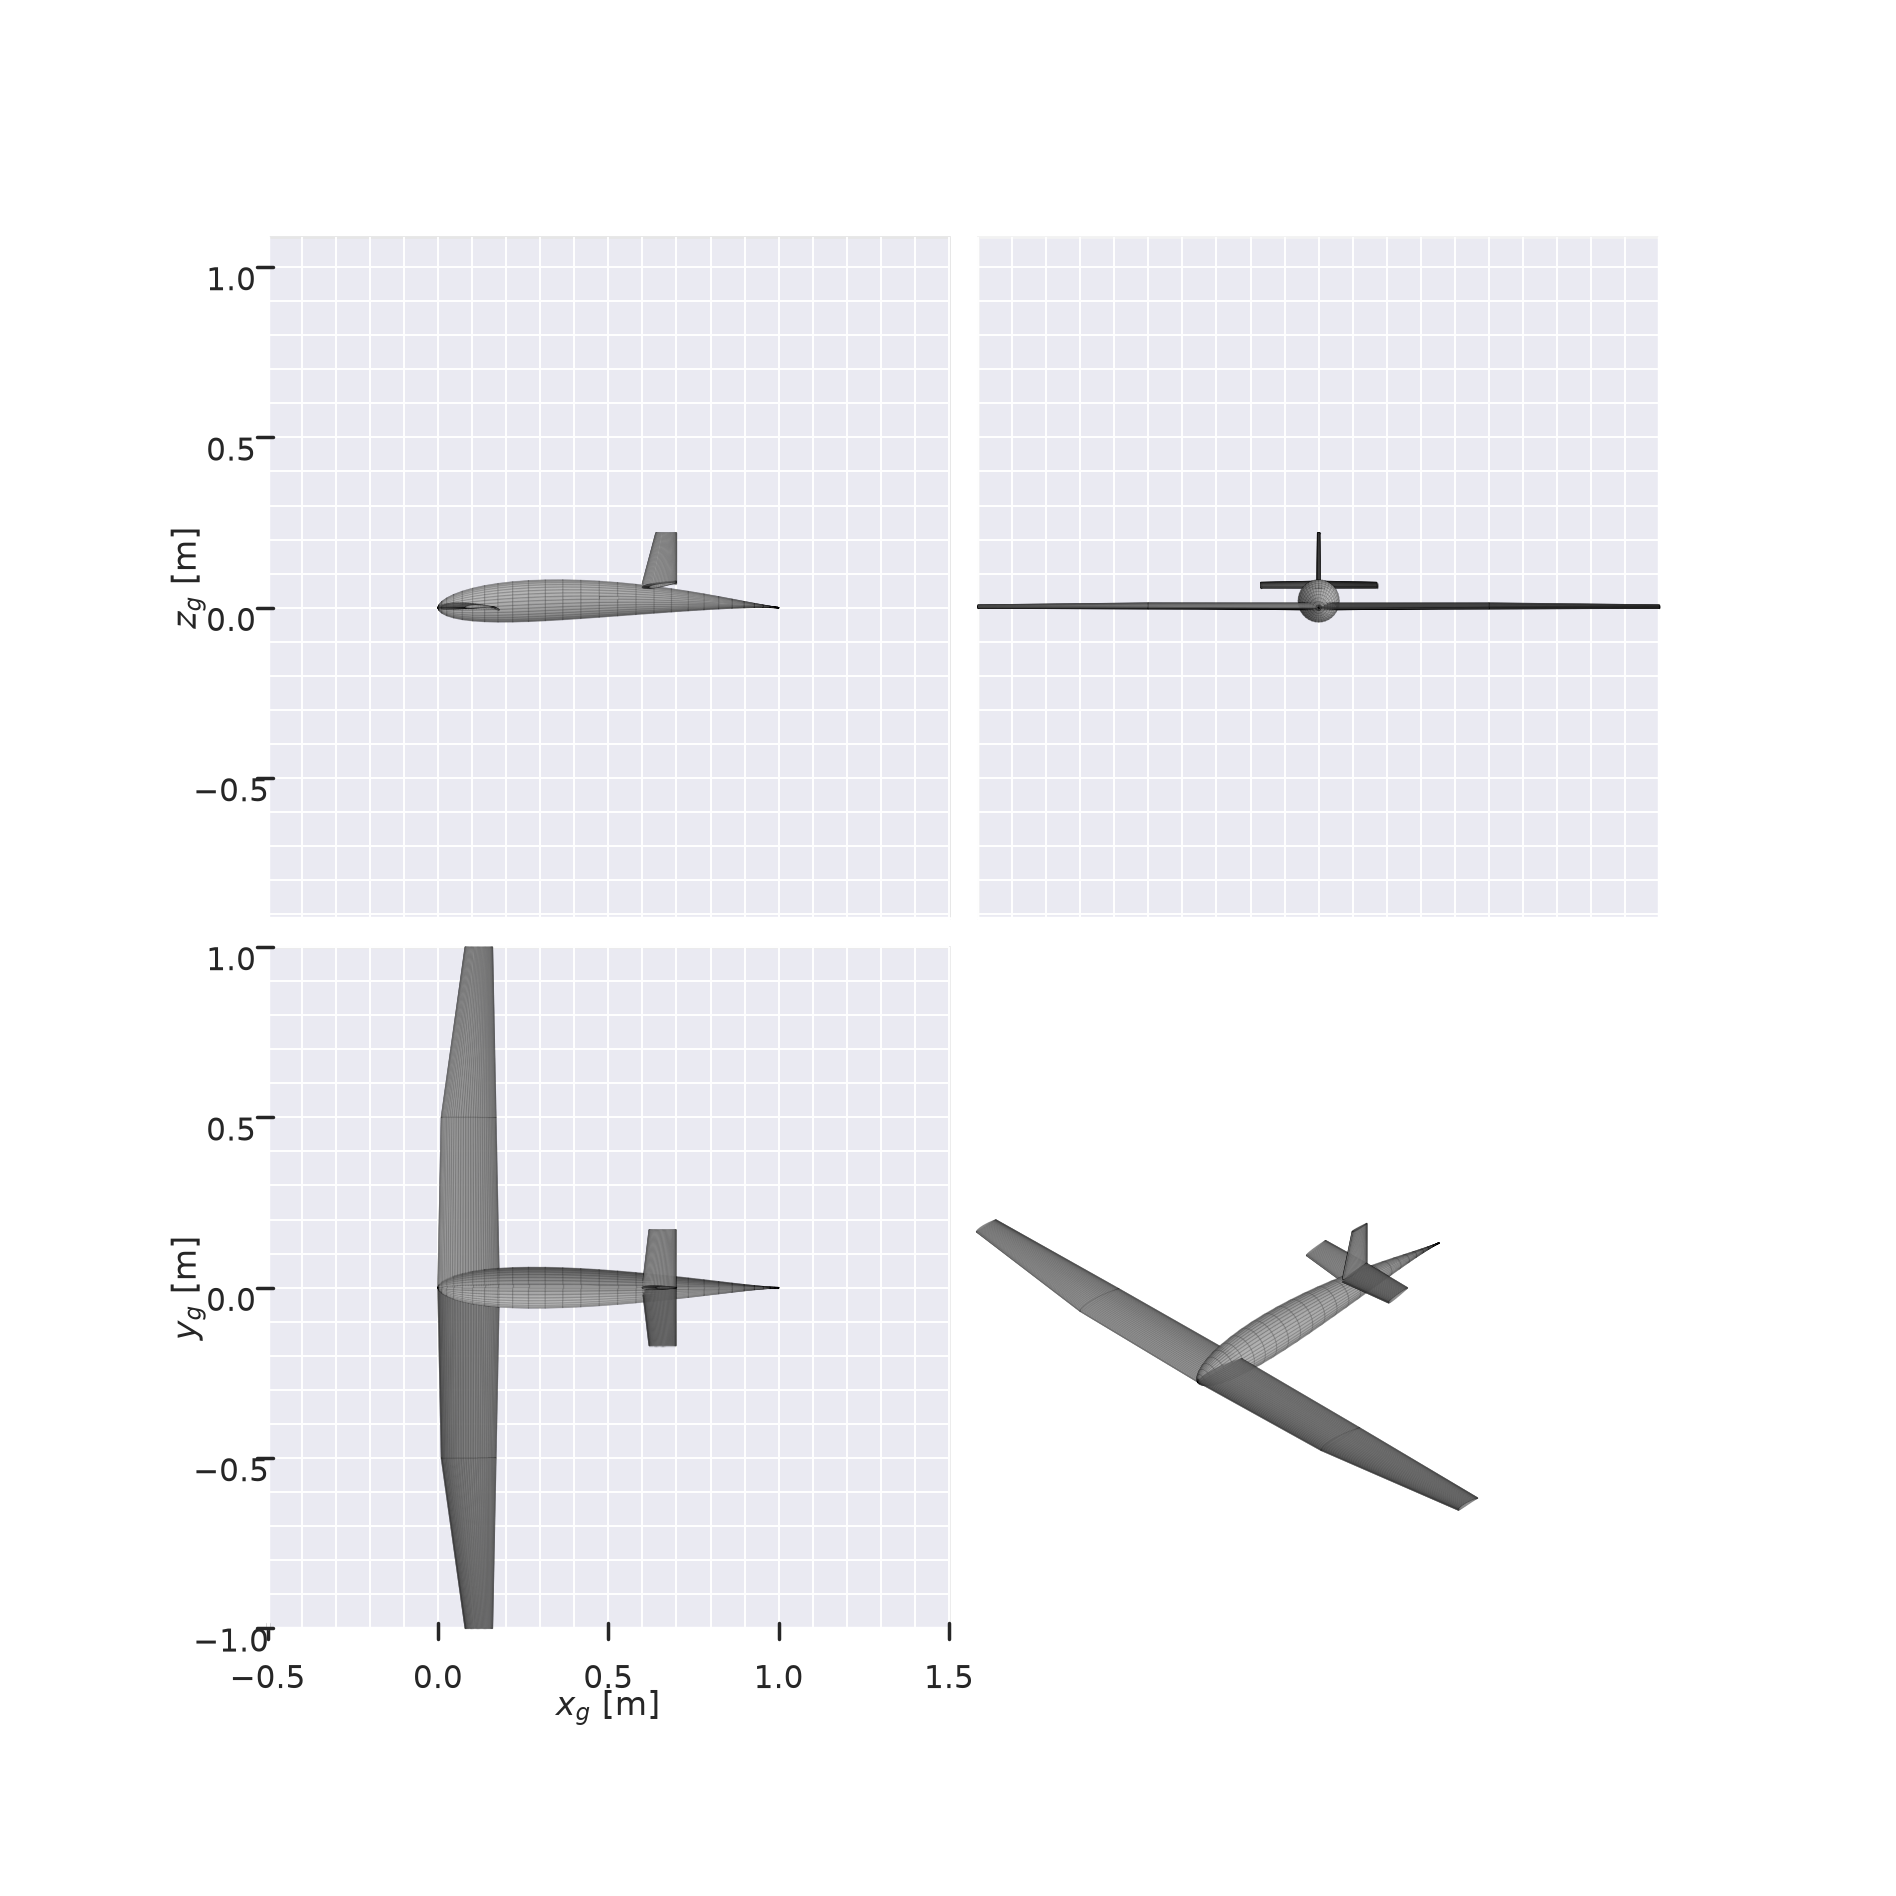

array([[<Axes3D: zlabel='$z_g$ [m]'>, <Axes3D: >],
       [<Axes3D: xlabel='$x_g$ [m]', ylabel='$y_g$ [m]'>, <Axes3D: >]],
      dtype=object)

In [35]:
airplane.draw_three_view()

In [36]:
aero = asb.AeroBuildup(
    airplane=airplane,
    op_point=asb.OperatingPoint(
        velocity=10,
        alpha=5,
    ),
)

print(aero.fuselage_aerodynamics(airplane.fuselages[0]))

AeroComponentResults(
	L=0.022381552134888544,
	Y=0.0,
	D=0.07940479266136297,
	l_b=-0.0,
	m_b=0.025101226523756813,
	n_b=-0.0,
	span_effective=0.12107395184627512, oswalds_efficiency=0.95,
)


In [38]:
alpha = np.linspace(-20, 20, 300)

aero = asb.AeroBuildup(
    airplane=airplane,
    op_point=asb.OperatingPoint(velocity=10, alpha=alpha, beta=0),
).run()

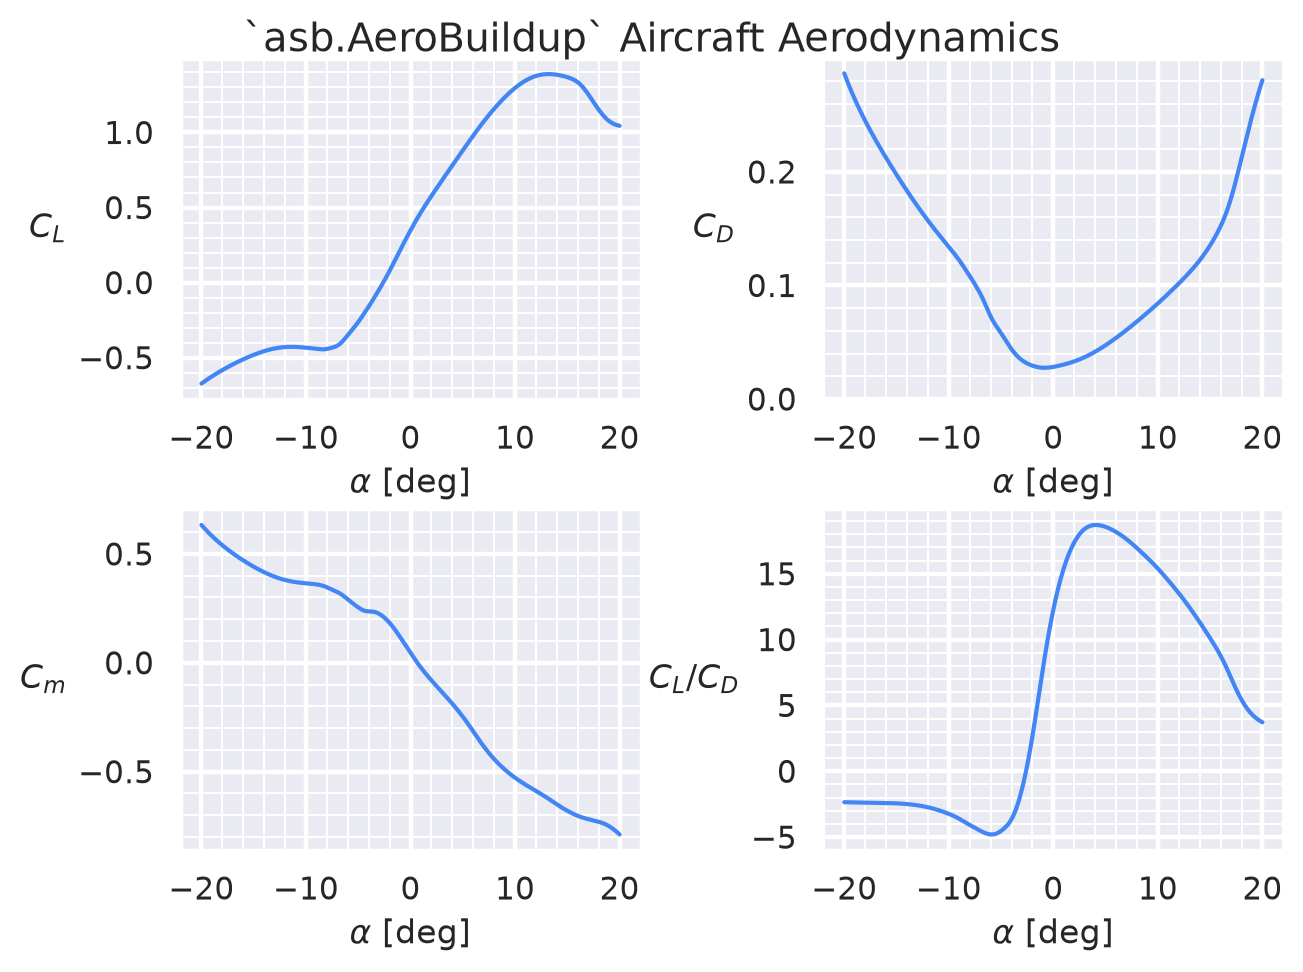

In [39]:
import matplotlib.pyplot as plt
import aerosandbox.tools.pretty_plots as p

fig, ax = plt.subplots(2, 2)

plt.sca(ax[0, 0])
plt.plot(alpha, aero["CL"])
plt.xlabel(r"$\alpha$ [deg]")
plt.ylabel(r"$C_L$")
p.set_ticks(5, 1, 0.5, 0.1)

plt.sca(ax[0, 1])
plt.plot(alpha, aero["CD"])
plt.xlabel(r"$\alpha$ [deg]")
plt.ylabel(r"$C_D$")
p.set_ticks(5, 1, 0.05, 0.01)
plt.ylim(bottom=0)

plt.sca(ax[1, 0])
plt.plot(alpha, aero["Cm"])
plt.xlabel(r"$\alpha$ [deg]")
plt.ylabel(r"$C_m$")
p.set_ticks(5, 1, 0.5, 0.1)

plt.sca(ax[1, 1])
plt.plot(alpha, aero["CL"] / aero["CD"])
plt.xlabel(r"$\alpha$ [deg]")
plt.ylabel(r"$C_L/C_D$")
p.set_ticks(5, 1, 10, 2)

p.show_plot("`asb.AeroBuildup` Aircraft Aerodynamics")